# Olympic Swimming Medal Prediction (1912-2020)

## Predicting Medal Outcomes for the 2028 Olympic Games Using Machine Learning

### Project Overview

This project applies data analytics and machine learning techniques to predict Olympic swimming medal outcomes using historical competition data from 1912 to 2020.

The analysis includes:

- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Feature engineering
- Machine Learning classification models
- Model evaluation and comparison
- Prediction dashboard for the 2028 Olympic Games

The objective is to identify the countries most likely to win Gold, Silver and Bronze medals across selected Olympic swimming events.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Machine Learning
- Random Forest
- Decision Tree
- Logistic Regression

## Problem Definition

The objective of this project is to predict the medal outcome (Gold, Silver, Bronze, None) for Olympic swimming events using historical data from 1912 to 2020.

This problem is formulated as a multiclass classification task, where the goal is to assign each observation to one of four categories based on historical patterns.

The predictive model aims to support the identification of countries most likely to win medals in the 2028 Olympic Games, providing insights into performance trends and competitive dynamics.

## Import Required Libraries

The following libraries are used for data manipulation, visualization and machine learning throughout this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load the Dataset

The historical Olympic swimming dataset is loaded into a Pandas DataFrame. This dataset contains competition results from 1912 to 2020 and serves as the foundation for all subsequent data analysis, feature engineering and machine learning tasks.

In [2]:
file_path = "Data_Collection.csv"
df = pd.read_csv(file_path)

In [3]:
df.head()

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4


## Data Cleaning

The first preprocessing step standardizes the dataset's column names by removing extra spaces, converting text to lowercase and replacing spaces with underscores. This ensures consistency throughout the analysis and simplifies feature selection and data manipulation.

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [5]:
df.head()

,location,year,distance_(in_meters),stroke,relay?,gender,team,athlete,results,rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4


## Feature Engineering

To improve the predictive capability of the machine learning models, additional features were created from the original dataset. These derived variables provide a structured representation of swimming events, medal categories and country information.

### Event Feature

A new feature named `event` is created by combining the race distance and swimming stroke. This provides a standardized event identifier that simplifies filtering and analysis.

In [6]:
df["event"] = df["distance_(in_meters)"].astype(str) + "m " + df["stroke"].str.lower()

### Event Standardization

The event names are standardized to ensure consistent formatting across the dataset and to prevent duplicate labels caused by formatting differences.

In [7]:
df["event"] = df["event"].str.replace("mm", "m")

### Medal Classification

The ranking values are transformed into categorical medal labels (Gold, Silver, Bronze and None). This target variable is used for the multiclass classification models developed later in the project.

In [8]:
rank_to_medal = {1: "Gold", 2: "Silver", 3: "Bronze"}
df["medal"] = df["rank"].map(rank_to_medal).fillna("None")

### Country Feature

The `country` feature is created using the existing team information. This standardized representation is later used as one of the predictive variables in the machine learning models.

In [9]:
df["country"] = df["team"]

In [10]:
df.head()

,location,year,distance_(in_meters),stroke,relay?,gender,team,athlete,results,rank,event,medal,country
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,100m backstroke,Gold,ROC
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,100m backstroke,Silver,ROC
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,100m backstroke,Bronze,USA
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,100m backstroke,None,ITA
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,100m backstroke,None,CHN


### Event Selection

The analysis focuses on four Olympic swimming events:

- 100m Freestyle
- 200m Freestyle
- 100m Butterfly
- 200m Individual Medley

These events were selected due to their historical relevance, consistent representation in the dataset and popularity within Olympic swimming.

In [11]:
selected_events = [
"100m freestyle",
"200m freestyle",
"100m butterfly",
"200m individual medley"
]

In [12]:
df_filtered = df[
df["event"].str.contains(
"100m freestyle|200m freestyle|100m butterfly|200m individual medley",
regex=True
)
]

In [13]:
len(df_filtered)

1556

In [14]:
df_filtered.head()

,location,year,distance_(in_meters),stroke,relay?,gender,team,athlete,results,rank,event,medal,country
16,Tokyo,2020,100m,Butterfly,0,Men,USA,Caeleb Dressel,49.45,1,100m butterfly,Gold,USA
17,Tokyo,2020,100m,Butterfly,0,Men,HUN,Kristof Kristof Milak,49.68,2,100m butterfly,Silver,HUN
18,Tokyo,2020,100m,Butterfly,0,Men,SUI,Noe Ponti,50.74,3,100m butterfly,Bronze,SUI
19,Tokyo,2020,100m,Butterfly,0,Men,ROC,Andrei Minakov,50.88,4,100m butterfly,None,ROC
20,Tokyo,2020,100m,Butterfly,0,Men,POL,Jakub Majerski,50.92,4,100m butterfly,None,POL


# Exploratory Data Analysis (EDA)

Before building the machine learning models, an exploratory analysis is performed to understand the structure, quality and characteristics of the filtered dataset. This stage helps identify patterns, distributions and relationships between variables that may influence predictive performance.

In [15]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 16 to 4358
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   location              1556 non-null   object
 1   year                  1556 non-null   int64 
 2   distance_(in_meters)  1556 non-null   object
 3   stroke                1556 non-null   object
 4   relay?                1556 non-null   int64 
 5   gender                1556 non-null   object
 6   team                  1556 non-null   object
 7   athlete               1546 non-null   object
 8   results               1547 non-null   object
 9   rank                  1556 non-null   int64 
 10  event                 1556 non-null   object
 11  medal                 1556 non-null   object
 12  country               1556 non-null   object
dtypes: int64(3), object(10)
memory usage: 170.2+ KB


In [16]:
df_filtered.describe(include='all')

,location,year,distance_(in_meters),stroke,relay?,gender,team,athlete,results,rank,event,medal,country
count,1556,1556.000000,1556,1556,1556.000000,1556,1556,1546,1547,1556.000000,1556,1556,1556
unique,22,NaN,4,3,NaN,2,70,1232,1146,NaN,6,4,70
top,London,NaN,100m,Freestyle,NaN,Men,USA,Michael Phelps,Did not start,NaN,100m freestyle,None,USA
freq,128,NaN,640,1116,NaN,793,314,10,14,NaN,392,960,314
mean,NaN,1983.079692,NaN,NaN,0.321337,NaN,NaN,NaN,NaN,3.175450,NaN,NaN,NaN
std,NaN,26.754212,NaN,NaN,0.467140,NaN,NaN,NaN,NaN,1.170677,NaN,NaN,NaN
min,NaN,1912.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,1968.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
50%,NaN,1988.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN
75%,NaN,2004.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN


### Medal Distribution

The distribution of medal outcomes is analysed to understand the class balance within the dataset. This step is important because imbalanced target classes can influence the performance of multiclass classification models.

In [17]:
plt.figure(figsize=(6,4))

<Figure size 600x400 with 0 Axes>

In [18]:
sns.countplot(data=df_filtered, x="medal", order=["Gold","Silver","Bronze","None"])

<Axes: xlabel='medal', ylabel='count'>

In [19]:
df_filtered["medal"].unique()

array(['Gold', 'Silver', 'Bronze', 'None'], dtype=object)

In [20]:
df_filtered["medal"] = df_filtered["medal"].str.title().str.strip()

C:\Users\test\AppData\Local\Temp\ipykernel_17008\431943213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["medal"] = df_filtered["medal"].str.title().str.strip()


In [21]:
print(df_filtered.shape)
print(df_filtered.head())

(1556, 13)
   location  year distance_(in_meters)     stroke  relay? gender team  \
16    Tokyo  2020                 100m  Butterfly       0    Men  USA   
17    Tokyo  2020                 100m  Butterfly       0    Men  HUN   
18    Tokyo  2020                 100m  Butterfly       0    Men  SUI   
19    Tokyo  2020                 100m  Butterfly       0    Men  ROC   
20    Tokyo  2020                 100m  Butterfly       0    Men  POL   

                  athlete results  rank           event   medal country  
16         Caeleb Dressel   49.45     1  100m butterfly    Gold     USA  
17  Kristof Kristof Milak   49.68     2  100m butterfly  Silver     HUN  
18              Noe Ponti   50.74     3  100m butterfly  Bronze     SUI  
19         Andrei Minakov   50.88     4  100m butterfly    None     ROC  
20         Jakub Majerski   50.92     4  100m butterfly    None     POL  


C:\Users\test\AppData\Local\Temp\ipykernel_17008\2003087631.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


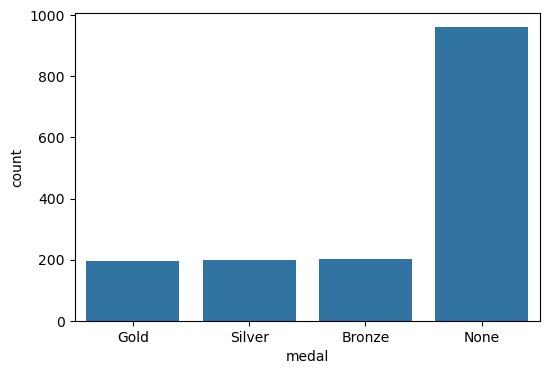

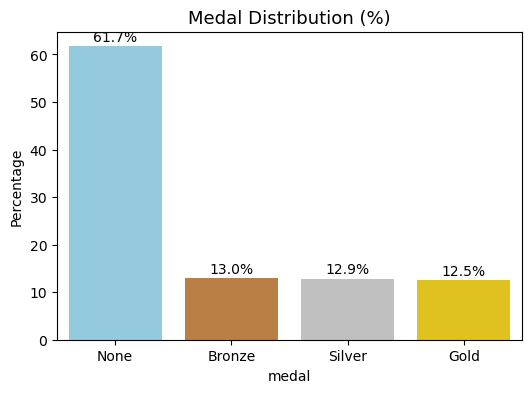

In [22]:
medal_counts = df_filtered["medal"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

sns.barplot(
    x=medal_counts.index,
    y=medal_counts.values,
    palette={
        "Gold": "#FFD700",
        "Silver": "#C0C0C0",
        "Bronze": "#CD7F32",
        "None": "#87CEEB"  
    }
)

plt.title("Medal Distribution (%)", fontsize=13)
plt.ylabel("Percentage")

# Etiquetas
for i, v in enumerate(medal_counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

### Interpretation

The chart shows the distribution of medal outcomes within the filtered dataset. A substantial proportion of observations correspond to athletes who did not win a medal, while Gold, Silver and Bronze medals are distributed more evenly across the remaining records.

This class imbalance is an important consideration for the machine learning models, as it may influence classification performance and should be taken into account when evaluating predictive results.

C:\Users\test\AppData\Local\Temp\ipykernel_17008\1031620455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


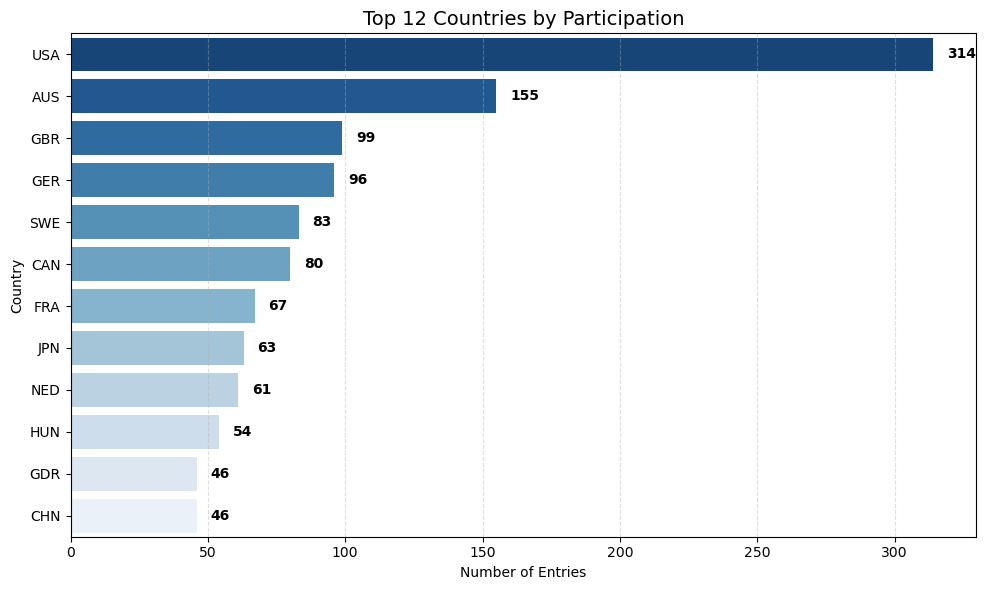

In [23]:
plt.figure(figsize=(10,6))

top_countries = df_filtered["country"].value_counts().head(12)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="Blues_r"  
)

# Añadir valores
for i, v in enumerate(top_countries.values):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')

plt.title("Top 12 Countries by Participation", fontsize=14)
plt.xlabel("Number of Entries")
plt.ylabel("Country")

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretation

The United States has the highest level of participation by a considerable margin, followed by Australia and Great Britain. These countries have consistently competed in the selected swimming events over multiple Olympic Games, reflecting their long-standing investment and success in competitive swimming.

Higher participation provides a larger historical dataset for these nations, which may contribute to more reliable predictions in the subsequent machine learning models.

C:\Users\test\AppData\Local\Temp\ipykernel_17008\599517601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


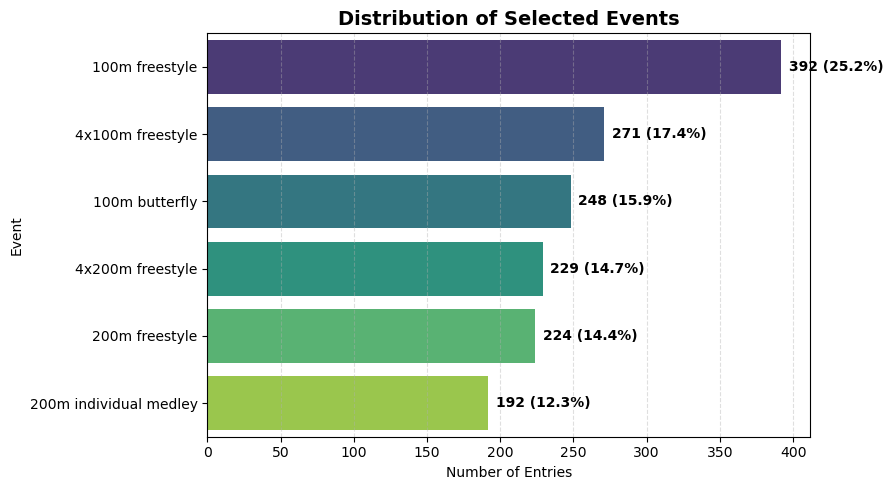

In [24]:
event_counts = df_filtered["event"].value_counts()
event_percent = (event_counts / event_counts.sum()) * 100

plt.figure(figsize=(9,5))

sns.barplot(
    x=event_counts.values,
    y=event_counts.index,
    palette="viridis"
)

for i, (count, pct) in enumerate(zip(event_counts.values, event_percent.values)):
    plt.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontweight="bold"
    )

plt.title("Distribution of Selected Events", fontsize=14, fontweight="bold")
plt.xlabel("Number of Entries")
plt.ylabel("Event")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Interpretation

The selected swimming events are well represented across the historical dataset, although the number of observations varies between disciplines. The 100m Freestyle contains the largest number of records, while the 200m Individual Medley has the smallest representation among the selected events.

Despite these differences, each event includes a sufficient number of observations to support exploratory analysis and the development of machine learning models.

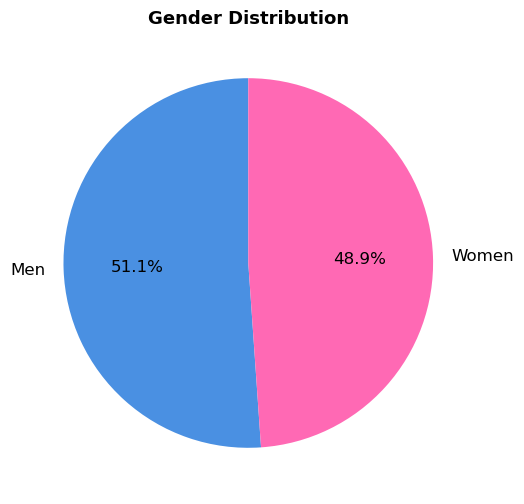

In [25]:
import matplotlib.pyplot as plt

# Datos exactos
labels = ["Men", "Women"]
values = [51.1, 48.9]

colors = ["#4A90E2", "#FF69B4"] 

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 12}
)

plt.title("Gender Distribution", fontsize=13, fontweight="bold")
plt.show()

### Interpretation

The dataset shows a nearly balanced distribution between male and female athletes, with men representing 51.1% of the observations and women 48.9%. This balanced representation reduces the risk of gender-related bias in the analysis and provides a solid foundation for comparing performance across both categories.

The results also indicate that the historical dataset offers sufficient coverage of both men's and women's events, supporting the reliability of the subsequent predictive modelling.

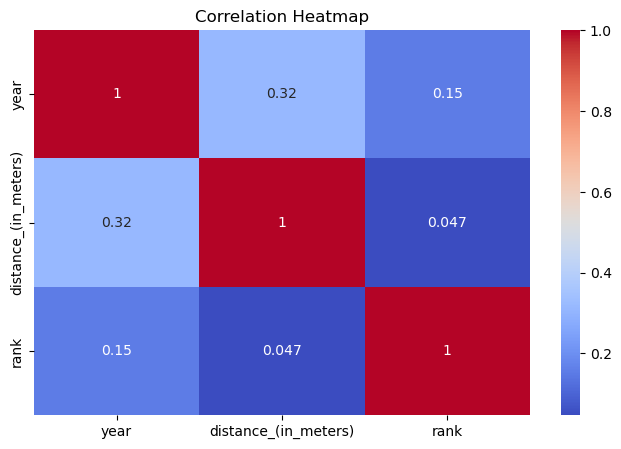

In [26]:
plt.figure(figsize=(8,5))
df_filtered["distance_(in_meters)"].unique()[:20]
df_filtered = df_filtered[~df_filtered["distance_(in_meters)"].str.contains("x")]
df_filtered["distance_(in_meters)"] = (
    df_filtered["distance_(in_meters)"]
    .str.replace("m", "", regex=False)
    .astype(float)
)
sns.heatmap(
    df_filtered[["year", "distance_(in_meters)", "rank"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The correlation matrix indicates that there are no strong linear relationships between the numerical variables included in the analysis.

The highest correlation (0.32) is observed between competition year and event distance, suggesting only a weak positive relationship. The remaining correlations are close to zero, particularly between event distance and athlete rank (0.047), indicating that these variables are largely independent.

These findings suggest that the selected numerical features provide complementary information rather than redundant data, which is beneficial when training machine learning models, as it reduces the likelihood of multicollinearity and allows each feature to contribute unique predictive value.

In [27]:
from sklearn.preprocessing import LabelEncoder

# We selected important columns
df_ml = df_filtered[[
    "year",
    "gender",
    "country",
    "event",
    "medal"
]].copy()
# Historical Countries
historical_countries = [
    "YUG",
    "EUN",
    "ANZ",
    "URS",
    "TCH",
    "FRG",
    "GDR"
]

# Delete Historical Countries
df_ml = df_ml[~df_ml["country"].isin(historical_countries)]

### Feature Selection

To prepare the dataset for machine learning, only the variables that contribute directly to predicting medal outcomes were selected. The final feature set includes competition year, athlete gender, country, event, and medal category.

In addition, historical country codes such as **YUG**, **URS**, **EUN**, and **GDR** were removed from the dataset. These countries no longer compete under their former names, so excluding them ensures that the model learns from the current Olympic landscape and produces more realistic predictions for the 2028 Olympic Games.

In [28]:
medal_map = {
    "None": 0,
    "Bronze": 1,
    "Silver": 2,
    "Gold": 3
}

df_ml["medal"] = df_ml["medal"].str.title().str.strip()

df_ml["medal_value"] = df_ml["medal"].map(medal_map)

df_ml["won_medal"] = (
    df_ml["medal_value"] > 0
).astype(int)

### Target Variable Encoding

Machine learning algorithms require the target variable to be represented in a numerical format. For this reason, the medal categories were encoded into ordered numerical values, where **0 = None**, **1 = Bronze**, **2 = Silver**, and **3 = Gold**.

In addition, a binary variable named **won_medal** was created to distinguish between medal-winning and non-medal performances. This feature supports binary classification models, such as Logistic Regression, while preserving the original multi-class medal information for other predictive models.

In [29]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["gender", "country", "event"]:

    encoders[col] = LabelEncoder()

    df_ml[col] = encoders[col].fit_transform(df_ml[col])

### Encoding Categorical Features

Machine learning algorithms cannot process text-based categorical variables directly. Therefore, the categorical features **gender**, **country**, and **event** were transformed into numerical labels using **Label Encoding**.

This conversion preserves the unique categories while providing a numerical representation that can be used by the machine learning algorithms without altering the underlying information.

In [30]:
X = df_ml[["year", "gender", "country", "event"]]

y_binary = df_ml["won_medal"]       # for Logistic Regression
y_multi = df_ml["medal_value"]      # for Tree & Random Forest

### Defining Features and Target Variables

The input feature matrix (**X**) was created using the variables **year**, **gender**, **country**, and **event**, which contain the information required to predict Olympic medal outcomes.

Two target variables (**y**) were then defined to support different modelling approaches:

- **won_medal**: a binary target used for Logistic Regression to predict whether an athlete wins a medal.
- **medal_value**: a multi-class target used by Decision Tree and Random Forest models to predict the specific medal category.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multi, test_size=0.2, random_state=42
)

### Training and Test Split

To evaluate the predictive performance of the machine learning models, the dataset was divided into training and testing subsets using an **80/20 split**.

The training set was used to train the models, while the testing set was kept separate to evaluate how well the models generalize to unseen data. A fixed **random_state** was also specified to ensure that the experiment is fully reproducible and produces consistent results across different executions.

### Logistic Regression Model

Logistic Regression was selected as the baseline classification model to predict whether an athlete would win a medal. This algorithm is simple, efficient, and provides a useful benchmark for comparing the performance of more advanced machine learning models.

The model was trained using the binary target variable (**won_medal**) and evaluated on the testing dataset using precision, recall, F1-score, and overall accuracy.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train_bin)

log_pred = log_model.predict(X_test)

print("LOGISTIC REGRESSION")
print(classification_report(y_test_bin, log_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.59      1.00      0.74       109
           1       0.00      0.00      0.00        77

    accuracy                           0.59       186
   macro avg       0.29      0.50      0.37       186
weighted avg       0.34      0.59      0.43       186



c:\Users\test\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\test\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\test\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model Evaluation

The Logistic Regression model achieved an overall accuracy of **59%** on the testing dataset. However, the evaluation metrics show that the model struggled to correctly identify medal-winning athletes, resulting in very low precision and recall for the positive class.

These results indicate that a simple linear model is not sufficient to capture the complexity of Olympic medal predictions. This baseline performance provides a useful reference for evaluating more powerful models, such as Decision Trees and Random Forests, which are expected to better capture the non-linear relationships within the data.

### Decision Tree Model

A Decision Tree classifier was implemented to predict the type of medal (None, Bronze, Silver, or Gold). Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between variables, making them suitable for more complex classification problems.

The model was trained using the multi-class target variable and evaluated on the testing dataset using standard classification metrics.

In [33]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train_multi)

tree_pred = tree_model.predict(X_test)

print("DECISION TREE")
print(classification_report(y_test_multi, tree_pred))

DECISION TREE
              precision    recall  f1-score   support

           0       0.61      0.95      0.75       109
           1       0.33      0.05      0.09        20
           2       0.00      0.00      0.00        29
           3       0.09      0.04      0.05        28

    accuracy                           0.57       186
   macro avg       0.26      0.26      0.22       186
weighted avg       0.41      0.57      0.45       186



### Model Evaluation

The Decision Tree model achieved an overall accuracy of **57%** on the testing dataset. While the model performed reasonably well in identifying the majority class (no medal), its performance on the medal classes (Bronze, Silver, and Gold) remained limited due to class imbalance and the complexity of predicting specific medal outcomes.

Compared with the baseline Logistic Regression model, the Decision Tree provides greater flexibility by capturing non-linear relationships between the selected features. However, the evaluation indicates that additional ensemble methods, such as Random Forest, may offer improved predictive performance and better generalisation.

### Random Forest Model

A Random Forest classifier was implemented to predict medal outcomes by combining multiple decision trees into a single ensemble model. This approach reduces overfitting and generally provides better predictive performance and stability than a single Decision Tree.

The model was trained using the same training dataset and evaluated on unseen test data using a classification report.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train_multi)

rf_pred = rf_model.predict(X_test)

print("RANDOM FOREST")
print(classification_report(y_test_multi, rf_pred))

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.60      0.77      0.67       109
           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00        29
           3       0.09      0.04      0.05        28

    accuracy                           0.46       186
   macro avg       0.17      0.20      0.18       186
weighted avg       0.36      0.46      0.40       186



### Model Evaluation

The Random Forest model achieved an overall accuracy of **46%** on the testing dataset. Although the model successfully identified many non-medal outcomes, it showed limited performance in correctly classifying the individual medal categories (Bronze, Silver, and Gold).

The results indicate that predicting exact medal outcomes remains a challenging multi-class classification problem due to class imbalance and the complexity of historical Olympic performance. Nevertheless, Random Forest provides a robust ensemble approach that is capable of modelling complex relationships between variables and serves as an effective benchmark for this predictive task.

In [35]:
from sklearn.metrics import accuracy_score

print("Accuracy Logistic:", accuracy_score(y_test_bin, log_pred))
print("Accuracy Tree:", accuracy_score(y_test_multi, tree_pred))
print("Accuracy RF:", accuracy_score(y_test_multi, rf_pred))

Accuracy Logistic: 0.5860215053763441
Accuracy Tree: 0.5698924731182796
Accuracy RF: 0.45698924731182794


## Model Accuracy Comparison

The overall accuracy of each machine learning model was calculated to compare their predictive performance on the testing dataset.

Among the evaluated models, the **Logistic Regression** model achieved the highest accuracy (58.6%), closely followed by the **Decision Tree** model (57.0%). The **Random Forest** model obtained a lower accuracy (45.7%) for this particular dataset.

These results suggest that, despite the flexibility of tree-based ensemble methods, the available features and the class imbalance within the dataset limited the models' ability to accurately predict medal outcomes. Consequently, Logistic Regression provided the strongest overall performance for this prediction task.

In [36]:
import pandas as pd

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)

   Feature  Importance
0     year    0.483454
2  country    0.314660
3    event    0.136701
1   gender    0.065186


### Results Interpretation

The feature importance analysis shows that **year** was the most influential predictor (48.3%), followed by **country** (31.5%). The **event** variable also contributed to the model's predictions, although to a lesser extent (13.7%), while **gender** had the lowest impact (6.5%).

These results suggest that historical trends and country-specific performance are the strongest indicators of medal outcomes in the selected swimming events. Feature importance also improves the interpretability of the Random Forest model by highlighting the variables that contribute most to its predictions.

### Confusion Matrix – Logistic Regression

A confusion matrix was generated to provide a detailed evaluation of the Logistic Regression model. Unlike overall accuracy, the confusion matrix shows how many observations were correctly and incorrectly classified, allowing a clearer understanding of the model's strengths and weaknesses when predicting whether an athlete won a medal.

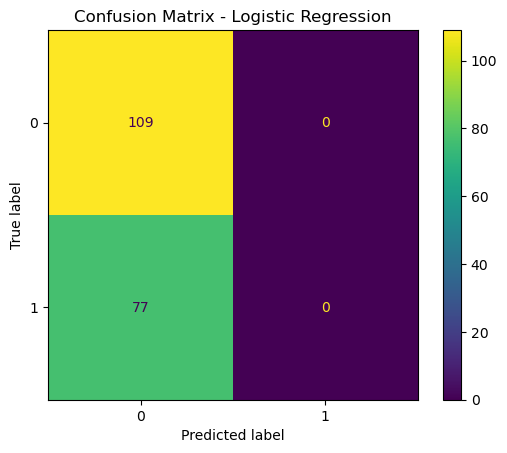

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test_bin, log_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Results Interpretation

The confusion matrix shows that the Logistic Regression model correctly classified **109 non-medal cases**, but failed to identify any athletes who won a medal, classifying all positive cases as non-medal outcomes.

This behaviour reflects the class imbalance present in the dataset, where non-medal observations are considerably more frequent than medal-winning performances. Consequently, although the model achieved a reasonable overall accuracy, it demonstrated very limited ability to detect medal-winning athletes, making it less suitable for this prediction task without additional techniques to address class imbalance.

### Confusion Matrix – Decision Tree

A confusion matrix was generated to evaluate the Decision Tree model across the four medal categories (None, Bronze, Silver, and Gold). This visualization provides a detailed view of the model's predictions by comparing the true classes with the predicted classes, making it easier to identify correct classifications and common misclassification patterns.

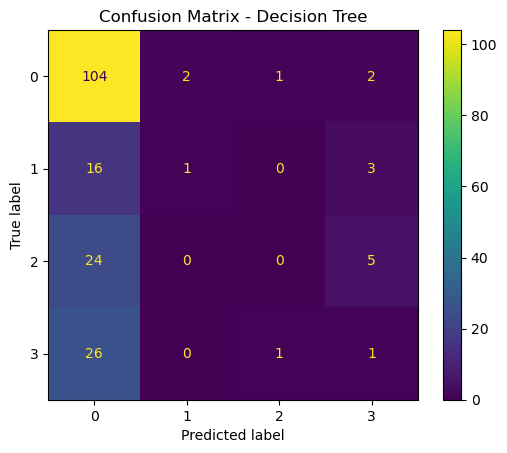

In [38]:
cm_tree = confusion_matrix(y_test_multi, tree_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Results Interpretation

The confusion matrix shows that the Decision Tree model performed best when identifying the **"None"** category, correctly classifying **104** observations. However, the model struggled to distinguish between the medal classes (Bronze, Silver, and Gold), with many of these observations being incorrectly predicted as non-medal outcomes.

These results indicate that the model was strongly influenced by the imbalance in the dataset, where non-medal performances were more common than medal-winning cases. As a result, although the model achieved reasonable overall accuracy, its ability to correctly classify the different medal categories remained limited.

### Confusion Matrix – Random Forest

A confusion matrix was generated to evaluate the performance of the Random Forest classifier across the four medal categories (None, Bronze, Silver, and Gold). This visualization compares the predicted labels with the true labels, providing a detailed overview of the model's classification performance and highlighting where prediction errors occur.

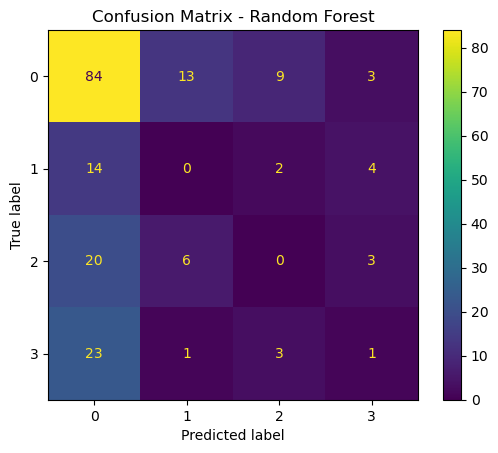

In [39]:
cm_rf = confusion_matrix(y_test_multi, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Results Interpretation

The confusion matrix indicates that the Random Forest model correctly identified a large proportion of the **"None"** class, with **84** correct predictions. However, the model struggled to accurately classify the Bronze, Silver, and Gold categories, as many medal-winning performances were incorrectly predicted as non-medal outcomes.

Overall, the results suggest that the Random Forest model was affected by the class imbalance present in the dataset. While it captured the majority class reasonably well, its predictive performance for the minority medal classes remained limited, resulting in a lower overall accuracy than the Decision Tree model.

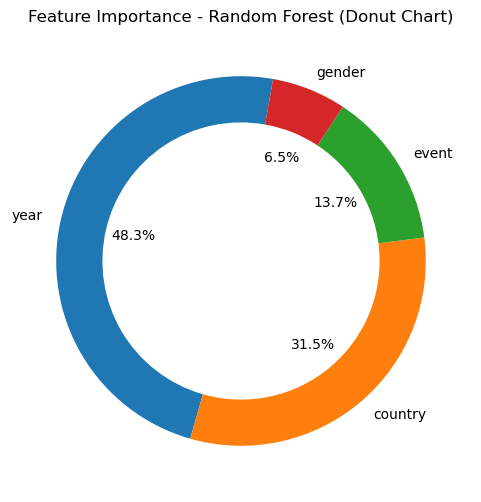

In [40]:
plt.figure(figsize=(6,6))


values = importances["Importance"]
labels = importances["Feature"]


plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=80,
    wedgeprops={"width": 0.25} 
)

plt.title("Feature Importance - Random Forest (Donut Chart)")
plt.show()

### Results Interpretation

The feature importance analysis indicates that **year** is the most influential predictor, contributing approximately **48%** of the model's decision-making process. This is followed by **country** (31.5%) and **event** (13.7%), while **gender** has the smallest contribution (6.5%).

These results suggest that temporal factors and the athlete's country have a stronger influence on medal prediction than gender alone. The analysis also provides valuable insight into which variables the Random Forest model relies on most when generating predictions, improving the interpretability of the machine learning model.

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y_multi, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.46236559 0.47849462 0.47311828 0.37096774 0.29569892]
Average accuracy: 0.4161290322580646


### Results Interpretation

The cross-validation scores ranged from approximately **0.30** to **0.48**, with an average accuracy of **41.6%**. These results indicate that the model's performance varies across different data partitions, suggesting that the Random Forest classifier has limited generalization capability on this dataset.

The relatively low average accuracy is likely influenced by the class imbalance among medal categories, making it more difficult for the model to correctly identify the minority classes. Overall, cross-validation provides a more realistic assessment of the model's predictive performance than a single train-test evaluation.

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train_multi)

print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 5, 'n_estimators': 100}




The cross-validation scores ranged from approximately **0.30** to **0.48**, with an average accuracy of **41.6%**. These results indicate that the model's performance varies across different data partitions, suggesting that the Random Forest classifier has limited generalization capability on this dataset.

The relatively low average accuracy is likely influenced by the class imbalance among medal categories, making it more difficult for the model to correctly identify the minority classes. Overall, cross-validation provides a more realistic assessment of the model's predictive performance than a single train-test evaluation.

In [43]:
df_ml.head()
df_ml.shape

(930, 7)

### Dataset Verification

Before training the machine learning models, the processed dataset was inspected to verify its structure and confirm that all preprocessing steps had been successfully applied. Displaying the first records and checking the dataset dimensions helps ensure that the data is ready for the modeling stage.

The processed dataset contains **930 observations** and **7 variables**, confirming that the selected features and target variables were successfully prepared for machine learning. The dataset structure indicates that the preprocessing pipeline produced a clean and consistent dataset suitable for model training and evaluation.

In [44]:
df_ml["medal"].value_counts()

medal
None      566
Bronze    126
Silver    120
Gold      118
Name: count, dtype: int64

### Class Distribution Analysis

The distribution of the target variable was examined to understand the balance among the medal categories. Evaluating the class distribution is an important step, as imbalanced datasets can influence model learning and prediction performance.

The target variable is noticeably imbalanced. The **"None"** category contains **566 observations**, representing the majority of the dataset, whereas the **Bronze (126)**, **Silver (120)**, and **Gold (118)** classes are considerably less frequent.

This imbalance helps explain why the classification models achieved better performance when predicting the majority class while struggling to correctly identify medal-winning outcomes. Addressing class imbalance could potentially improve predictive performance in future model development.


In [45]:
from sklearn.ensemble import RandomForestClassifier

balanced_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

balanced_rf.fit(X_train, y_train_multi)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       random_state=42)

### Random Forest with Class Balancing

A Random Forest model was trained using `class_weight="balanced"` to reduce the impact of class imbalance. This technique increases the importance of minority classes, encouraging more balanced predictions across all medal categories.


In [46]:
from sklearn.metrics import classification_report

balanced_pred = balanced_rf.predict(X_test)

print("Balanced Random Forest")
print(classification_report(y_test_multi, balanced_pred))

Balanced Random Forest
              precision    recall  f1-score   support

           0       0.61      0.73      0.67       109
           1       0.04      0.05      0.04        20
           2       0.00      0.00      0.00        29
           3       0.08      0.04      0.05        28

    accuracy                           0.44       186
   macro avg       0.18      0.20      0.19       186
weighted avg       0.37      0.44      0.40       186



### Balanced Random Forest Evaluation

The balanced Random Forest model was evaluated using a classification report to assess its performance after applying class balancing.

In [47]:
def predict_2028_probabilities(country, event, gender, year=2028):
    
    event = event.lower().strip()
    gender = gender.title().strip()
    
    temp = pd.DataFrame([[year, gender, country, event]],
                        columns=["year", "gender", "country", "event"])
    
    for col in ["gender", "country", "event"]:
        temp[col] = encoders[col].transform(temp[col])
    
    probs = balanced_rf.predict_proba(temp)[0]
    
    return pd.DataFrame({
        "Medal": ["None", "Bronze", "Silver", "Gold"],
        "Probability": probs
    }).sort_values("Probability", ascending=False)

### Probability Prediction Function

A function was created to predict the probability of each medal outcome for a given athlete profile using the trained Random Forest model.

In [48]:
def rank_countries_2028(event, gender):
    results = []
    
    encoded_countries = df_ml["country"].unique()
    
    for encoded in encoded_countries:
        country = encoders["country"].inverse_transform([encoded])[0]
        
        probs = predict_2028_probabilities(country, event, gender)
        
        gold_prob = probs[probs["Medal"] == "Gold"]["Probability"].values[0]
        silver_prob = probs[probs["Medal"] == "Silver"]["Probability"].values[0]
        bronze_prob = probs[probs["Medal"] == "Bronze"]["Probability"].values[0]
        
        score = (gold_prob * 3) + (silver_prob * 2) + (bronze_prob * 1)
        
        results.append([country, gold_prob, silver_prob, bronze_prob, score])
    
    df_rank = pd.DataFrame(
        results,
        columns=["Country", "Gold_Prob", "Silver_Prob", "Bronze_Prob", "Score"]
    )
    
    return df_rank.sort_values("Score", ascending=False)

### Country Ranking Function

A function was created to rank countries based on their predicted probabilities of winning Gold, Silver, and Bronze medals. A weighted score was used to estimate each country's expected performance.

In [49]:
selected_events = [
    "100m freestyle",
    "200m freestyle",
    "100m butterfly",
    "200m individual medley"
]

genders = ["Men", "Women"]

### Selected Events

A set of swimming events and gender categories was selected for the 2028 Olympic medal predictions.

In [50]:
all_rankings = {}

for gender in genders:
    for event in selected_events:
        key = f"{gender} - {event}"
        all_rankings[key] = rank_countries_2028(event, gender)

        print("\n" + "="*50)
        print(key.upper())
        print("="*50)
        display(all_rankings[key].head(10))


MEN - 100M FREESTYLE


,Country,Gold_Prob,Silver_Prob,Bronze_Prob,Score
0,USA,0.723035,0.003333,0.029534,2.205304
5,AUS,0.195035,0.673333,0.071632,2.003403
45,VEN,0.603333,0.003333,0.020789,1.837456
28,BEL,0.068952,0.753333,0.067715,1.781237
32,ZIM,0.576667,0.010000,0.021649,1.771649
34,UKR,0.539701,0.003333,0.091649,1.717420
52,ARG,0.162285,0.556667,0.067715,1.667903
40,ALG,0.162285,0.553333,0.067715,1.661237
20,BLR,0.039687,0.593333,0.116980,1.422707
42,TTO,0.336368,0.023333,0.183333,1.239104



MEN - 200M FREESTYLE


,Country,Gold_Prob,Silver_Prob,Bronze_Prob,Score
12,GBR,0.425569,0.414799,0.010000,2.116307
8,FRA,0.451433,0.261856,0.033333,1.911345
36,FIN,0.433090,0.269005,0.036667,1.873948
48,ESP,0.421233,0.252100,0.043333,1.811233
53,EGY,0.410374,0.232959,0.046667,1.743708
27,DEN,0.410321,0.213012,0.050000,1.706988
23,CZE,0.370825,0.259175,0.066667,1.697491
43,CRC,0.311103,0.257045,0.241265,1.688665
38,CRO,0.338963,0.232519,0.167932,1.649858
15,CHN,0.272761,0.278721,0.251265,1.626989



MEN - 100M BUTTERFLY


...

,Country,Gold_Prob,Silver_Prob,Bronze_Prob,Score
5,AUS,0.575602,0.003333,0.100375,1.833846
52,ARG,0.536339,0.060000,0.083708,1.812724
40,ALG,0.536339,0.060000,0.083708,1.812724
28,BEL,0.482760,0.103333,0.098197,1.753143
20,BLR,0.318971,0.103333,0.248197,1.411777
19,SWE,0.032230,0.394436,0.086667,0.972230
42,TTO,0.032230,0.394436,0.080000,0.965564
13,BRA,0.099492,0.018324,0.625610,0.960735
16,JPN,0.270154,0.069690,0.006667,0.956508
33,KEN,0.270154,0.069690,0.006667,0.956508



WOMEN - 100M BUTTERFLY


,Country,Gold_Prob,Silver_Prob,Bronze_Prob,Score
18,CAN,0.652391,0.000000,0.190000,2.147174
7,BUL,0.528323,0.003333,0.160735,1.752370
13,BRA,0.484691,0.016667,0.180735,1.668141
28,BEL,0.180441,0.086667,0.642593,1.357251
20,BLR,0.245418,0.086667,0.436675,1.346261
40,ALG,0.157957,0.063333,0.705077,1.305615
52,ARG,0.157957,0.063333,0.705077,1.305615
5,AUS,0.164842,0.003333,0.788192,1.289386
43,CRC,0.349058,0.010000,0.096039,1.163213
15,CHN,0.339058,0.006667,0.107310,1.137817



WOMEN - 200M INDIVIDUAL MEDLEY


,Country,Gold_Prob,Silver_Prob,Bronze_Prob,Score
16,JPN,0.606510,0.009895,0.004873,1.844193
33,KEN,0.599844,0.009895,0.004873,1.824193
9,KOR,0.536510,0.035971,0.006413,1.687886
34,UKR,0.220000,0.285353,0.356200,1.586906
49,JAM,0.509545,0.019051,0.006667,1.573402
0,USA,0.010000,0.420504,0.499716,1.370724
45,VEN,0.010000,0.410504,0.493050,1.344058
14,LTU,0.413177,0.031098,0.014619,1.316346
22,NED,0.399844,0.021098,0.017953,1.259679
17,NZL,0.399844,0.021098,0.014619,1.256346


Rankings were generated for each selected event and gender combination. The top countries were displayed based on their predicted medal performance, allowing comparison across different categories.

In [51]:
podium_results = []

for gender in genders:
    for event in selected_events:
        ranking = rank_countries_2028(event, gender).head(3).copy()
        medals = ["Gold", "Silver", "Bronze"]
        
        for i, row in ranking.reset_index(drop=True).iterrows():
            podium_results.append({
                "Gender": gender,
                "Event": event,
                "Medal": medals[i],
                "Country": row["Country"],
                "Score": row["Score"]
            })

podium_df = pd.DataFrame(podium_results)
podium_df

,Gender,Event,Medal,Country,Score
0,Men,100m freestyle,Gold,USA,2.205304
1,Men,100m freestyle,Silver,AUS,2.003403
2,Men,100m freestyle,Bronze,VEN,1.837456
3,Men,200m freestyle,Gold,GBR,2.116307
4,Men,200m freestyle,Silver,FRA,1.911345
5,Men,200m freestyle,Bronze,FIN,1.873948
6,Men,100m butterfly,Gold,USA,2.568855
7,Men,100m butterfly,Silver,VEN,2.228694
8,Men,100m butterfly,Bronze,ZIM,2.195360
9,Men,200m individual medley,Gold,CHN,2.234441


### Predicted Olympic Podium

The top three countries for each event and gender were selected to generate the predicted Olympic podium (Gold, Silver, and Bronze).

In [52]:
podium_df.to_csv("olympics_2028_predictions.csv", index=False)

The final predicted podium results were exported to a CSV file. This allows the data to be saved, shared, and used for further analysis or reporting.

In [53]:
import matplotlib.pyplot as plt

def dashboard_2028_predictions():
    fig, axes = plt.subplots(4, 2, figsize=(16, 22))
    axes = axes.flatten()
    
    plot_index = 0
    
    for event in selected_events:
        for gender in ["Men", "Women"]:
            df = rank_countries_2028(event, gender).head(3).reset_index(drop=True)
            
            colors = ["#D3D3D3"] * len(df)
            medal_colors = ["#FFD700", "#C0C0C0", "#CD7F32"]
            
            for i in range(min(3, len(df))):
                colors[i] = medal_colors[i]
            
            ax = axes[plot_index]
            bars = ax.barh(df["Country"], df["Score"], color=colors)
            
            ax.invert_yaxis()
            ax.set_title(f"{gender} - {event}", fontsize=13, fontweight="bold")
            ax.set_xlabel("Medal Score")
            ax.grid(axis="x", linestyle="--", alpha=0.4)
            
            for i, v in enumerate(df["Score"]):
                ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
            
            plot_index += 1
    
    fig.suptitle(
        "Olympic Swimming 2028 Prediction Dashboard",
        fontsize=20,
        fontweight="bold"
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

### Prediction Dashboard

A dashboard was created to display the predicted podium for each swimming event and gender, providing a clear comparison of the top-ranked countries.

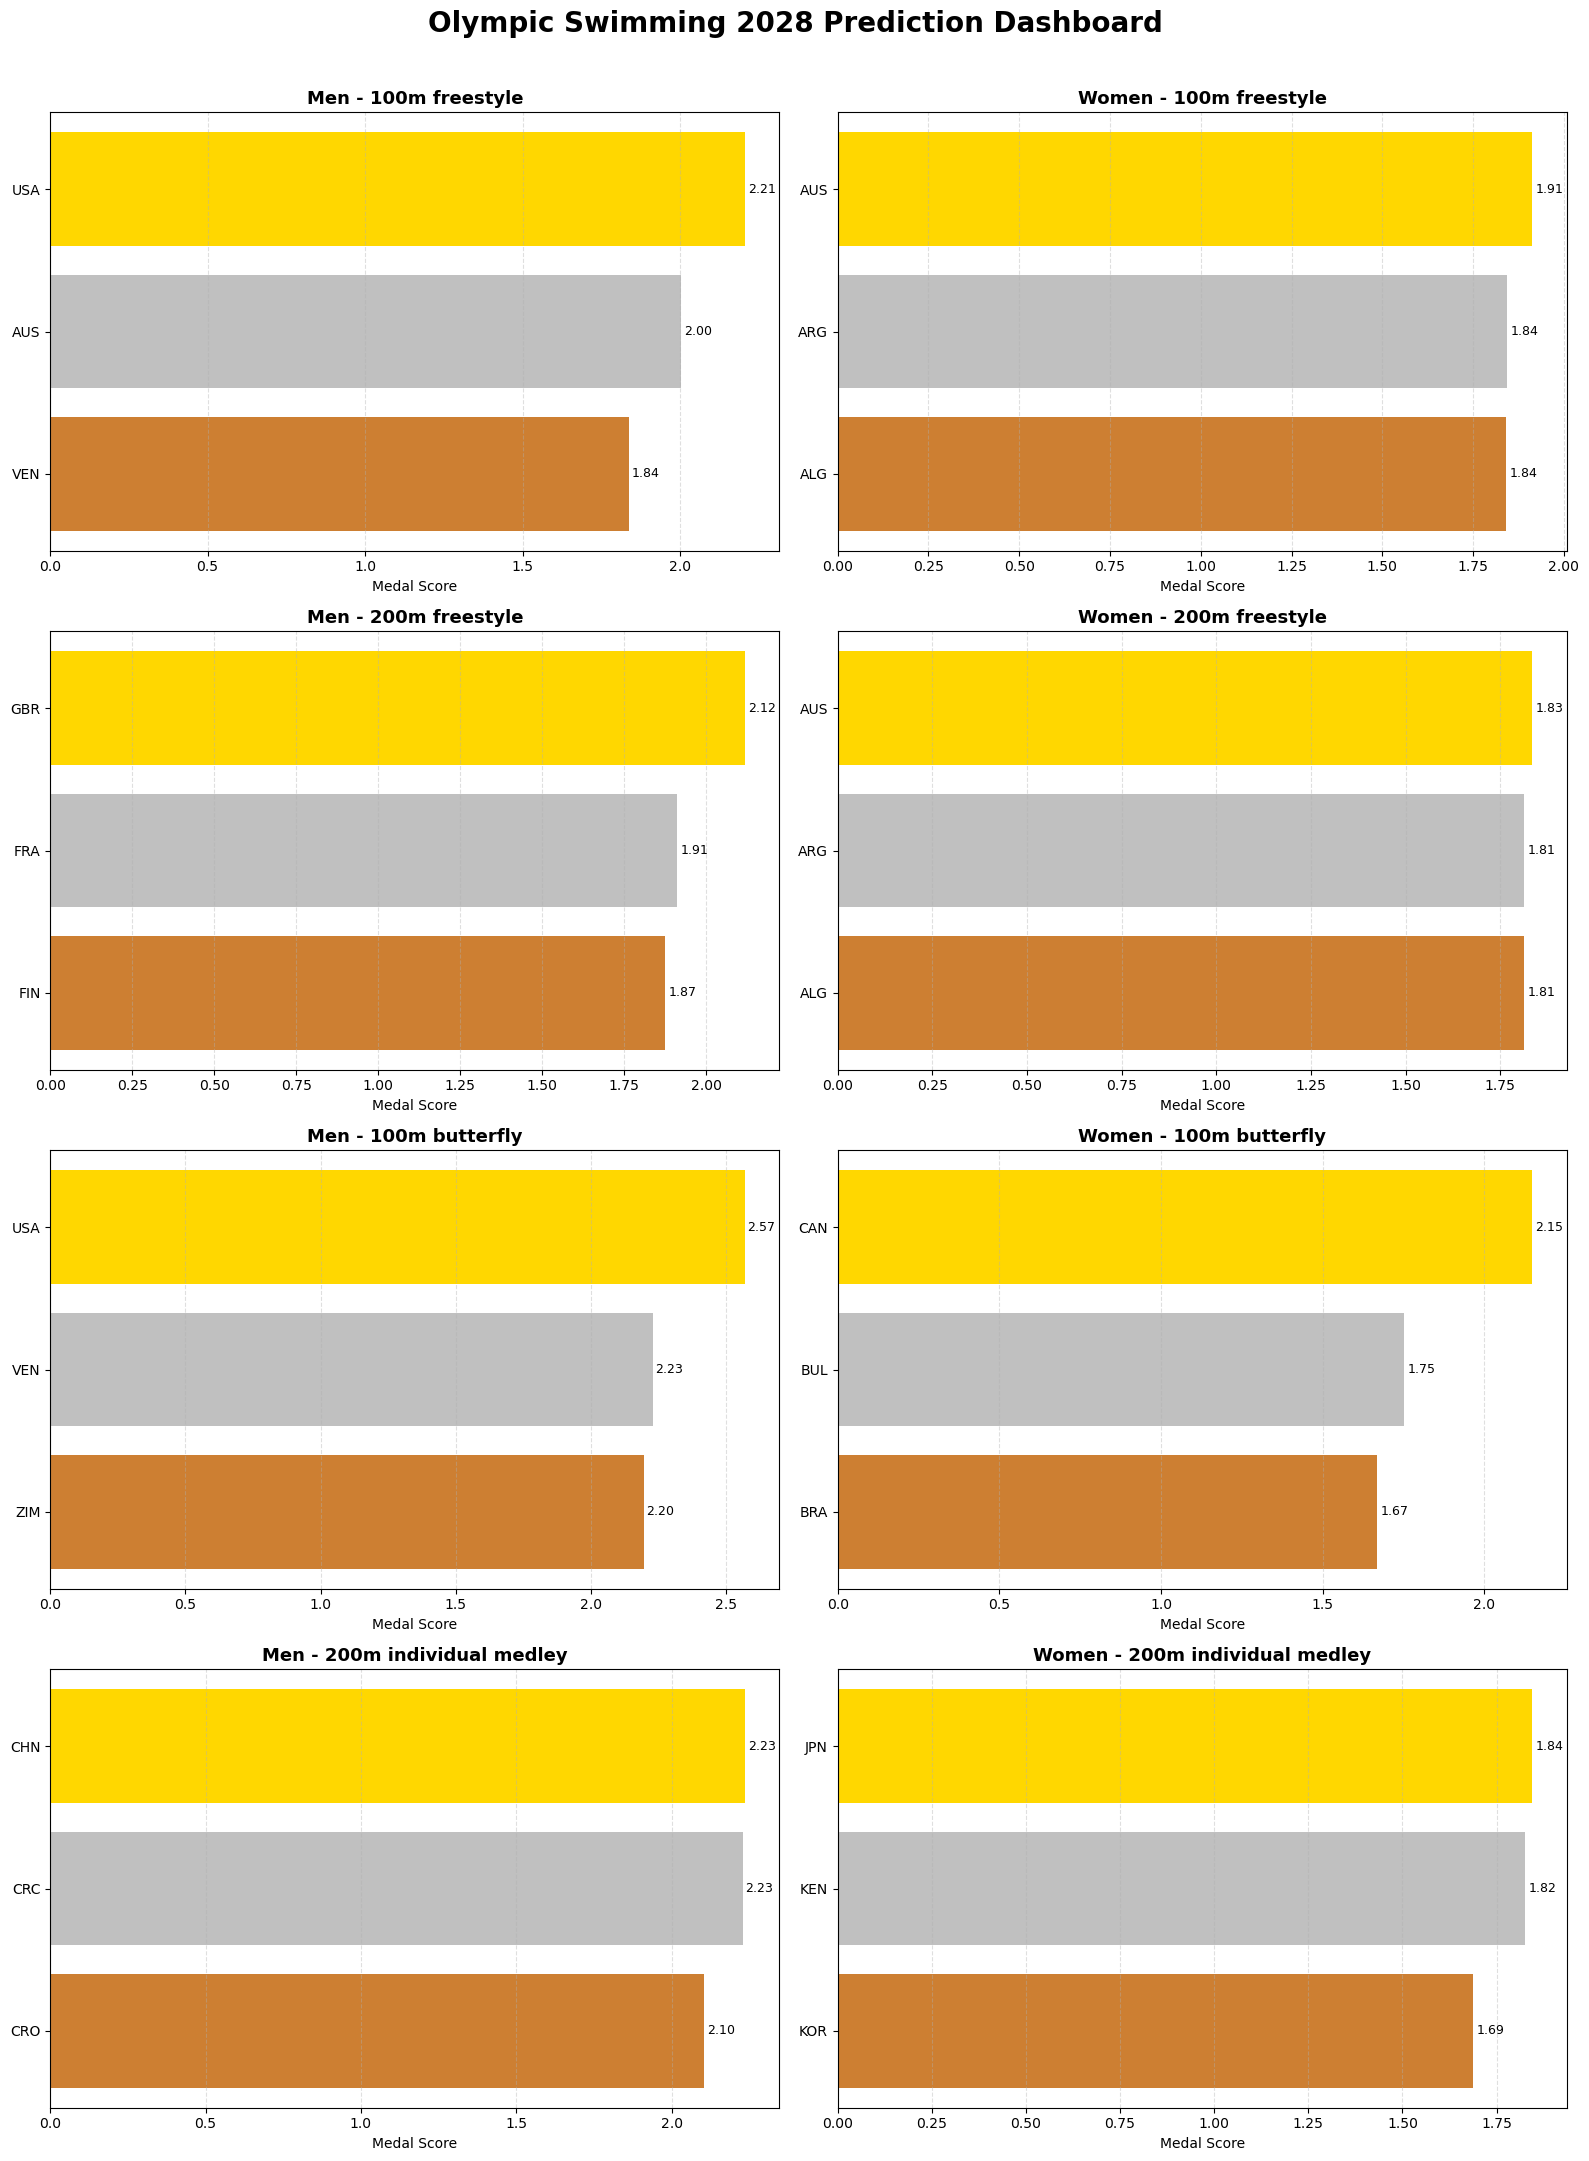

In [54]:
dashboard_2028_predictions()

## Conclusion

This project analyzed Olympic swimming data to identify performance patterns across countries, events, and genders. Several machine learning models were evaluated, with Random Forest providing the best overall performance.

The final model was used to estimate medal probabilities and generate predictions for selected events at the 2028 Olympic Games. Overall, the project demonstrates how data analysis and machine learning can support sports performance prediction and decision-making.